In [1]:
import os
import random
import pickle as pkl
from tqdm import tqdm
import math

from dataclasses import dataclass

from scipy.stats import entropy

from sklearn.linear_model import LogisticRegression

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from scipy.special import softmax
import torch
import numpy as np
from sklearn.model_selection import train_test_split
from transformers import pipeline
import pandas as pd

from personal_llm.utils import *
from scipy.stats import dirichlet

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')
import matplotlib.pylab as plt


In [2]:
# def get_person_choices(w_person, data, reward_models, n_response, rank_ind=0):

#     person_choices = []
#     for i in range(len(data)):

#         row = data.iloc[i]
#         item_scores = []
#         for rm_idx, rm in enumerate(reward_models):
#             rm_scores = []
#             for j in range(n_response):
#                 score = row["response_{}_{}".format(j+1, rm)]
#                 rm_scores.append(score)
#             # if args.softmax:
#             #     rm_scores = softmax(np.array(rm_scores)) * w_person[rm_idx]
#             # else:
#             #     rm_scores = np.array(rm_scores) * w_person[rm_idx]
#             rm_scores = np.array(rm_scores) * w_person[rm_idx]
#             item_scores.append(rm_scores)

#         item_scores = np.array(item_scores)
#         item_scores = np.sum(item_scores, 0)
#         sorted_ind = np.argsort(-item_scores)
#         # print("sorted ind", sorted_ind)
#         # print("argmin", np.argmin(item_scores))
#         # print("argmax", np.argmax(item_scores))
#         # e += 7
#         person_choices.append(sorted_ind[rank_ind])
#         # if args.worst_response:
#             # person_choices.append()
#         # else:
#             # person_choices.append(np.argmax(item_scores))

#     return person_choices
 
def get_person_choices(w_person, data, reward_models, n_response, all_rm_scores, rank_ind=0):

    person_choices = []
    for i in range(len(data)):

        row = data.iloc[i]
        item_scores = []
        for rm_idx, rm in enumerate(reward_models):
            rm_scores = all_rm_scores[i,rm_idx,:]
            rm_scores = rm_scores * w_person[rm_idx]
            # rm_scores = softmax(np.array(rm_scores)) * w_person[rm_idx]
            item_scores.append(rm_scores)

        item_scores = np.array(item_scores)
        item_scores = np.sum(item_scores, 0)
        sorted_ind = np.argsort(-item_scores)
        person_choices.append(sorted_ind[rank_ind])

    return person_choices
 

In [3]:
@dataclass
class Args:
    seed: int=0
    alpha: float=0.05
    n_persons: int=1000
    quantity_on_hand: int = 0
    worst_response: bool=False
    softmax: bool=False
    n_response: int=8


args = Args()

In [4]:
np.random.seed(args.seed)
random.seed(args.seed)
torch.manual_seed(args.seed)

_, reward_models = get_persons_and_reward_models()
train_data, test_data = get_data()

n_rm = len(reward_models)
alphas = np.array([args.alpha]*n_rm)
print("alphas", alphas)
persons = dirichlet.rvs(alphas, size=args.n_persons, random_state=args.seed)
print("persons", persons.shape)

alphas [0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05]
persons (1000, 10)


In [5]:
data = train_data

In [6]:
all_rm_scores = []
for i in range(len(data)):

    row = data.iloc[i]
    item_scores = []
    for rm_idx, rm in enumerate(reward_models):
        rm_scores = []
        for j in range(args.n_response):
            score = row["response_{}_{}".format(j+1, rm)]
            rm_scores.append(score)
        rm_scores = np.array(rm_scores)
        item_scores.append(rm_scores)
    all_rm_scores.append(item_scores)
    
all_rm_scores = np.array(all_rm_scores)
print(all_rm_scores.shape)

all_choices = []
for i in tqdm(range(persons.shape[0])):
    person = persons[i]
    choices = get_person_choices(person, data, reward_models, args.n_response, all_rm_scores, rank_ind=0)
    all_choices.append(choices)
best_choices = np.array(all_choices)
print(best_choices.shape)

(9402, 10, 8)


100%|██████████| 1000/1000 [13:50<00:00,  1.20it/s]


(1000, 9402)


In [7]:
results = []

for i in range(len(data)):

    prompt = data.iloc[i]["prompt"]
    id = data.iloc[i]["id"]
    votes = list(best_choices[:,i])
    vote_dist = np.zeros(args.n_response)

    for j in range(args.n_response):
        vote_dist[j] = votes.count(j)/args.n_persons
    
    ent = entropy(vote_dist)
    results.append([ent, id, prompt])

results = sorted(results)

least_ent = results[:40]
most_ent = results[-10:]

print("ENTROPY BASED")
print("Low Diversity")
for r in least_ent:
    print("Prompt:", r)
print("--------------")
print("High Diversity")
for r in most_ent:
    print("Prompt:", r)
    

ENTROPY BASED
Low Diversity
Prompt: [0.0, 529, 'Where is Kutztown University?']
Prompt: [0.0, 566, 'Give the news title a category. Pick a category from the list of News & Buzz, Travel, Style, Arts & Culture, Politics, Tech, and Science & Health.\n\nThe #Banksy Exhibit in Cambridge, MA is absolutely terrific.']
Prompt: [0.0, 1576, 'Can you combine the following sentences using compound subjects, verbs, and objects? Lions eat gazelles. Lions eat warthogs.']
Prompt: [0.0, 2281, 'How many NBA conferences are there?']
Prompt: [0.0, 2590, 'Can you change the verb in the following sentences into the past simple?\n\nI hear a new song on the radio.\nThey speak French to the bartender.\nHe swims 500m.\nThe children sleep in the car.\nWe leave the house at 7am.']
Prompt: [0.0, 2629, 'I want to know in what year the Corvette was introduced.']
Prompt: [0.0, 3539, 'I heard this bible verse today and I was wondering if you could tell me what book it was from. It goes like this:                      

In [10]:
plot_data = []
plot_labels = []

for sbj_word in [
    # "advice",
    "imagine",
    "opinion",
    "poem", 
    # "story", 
    # "flavor", 
    "taste", 
    # "favorite", 
    # "best",
    # "recommend",
    # "suggest",
    # "describe",
    
]:

    results = []
    sbj = []
    obj = []

    for i in range(len(data)):

        prompt = data.iloc[i]["prompt"]
        id = data.iloc[i]["id"]
        votes = list(best_choices[:,i])
        vote_dist = np.zeros(args.n_response)

        for j in range(args.n_response):
            vote_dist[j] = votes.count(j)/args.n_persons
        
        # ent = 1-np.max(vote_dist)
        ent = entropy(vote_dist)
        results.append([ent, id, prompt])

        if sbj_word in prompt.lower():
            sbj.append(ent)
        if ("When" in prompt):
            obj.append(ent)

    sorted_results = sorted(results)

    least_ent = sorted_results[:10]
    most_ent = sorted_results[-10:]

    # print("MAX SCORE BASED")
    # print("Low Diversity")
    # for r in least_ent:
    #     print("Prompt:", r)
    # print("--------------")
    # print("High Diversity")
    # for r in most_ent:
    #     print("Prompt:", r)
        
    print()
    print(sbj_word)
    print(len(sbj), len(obj))
    print(np.mean(sbj), np.std(sbj)/len(sbj), np.mean([r[0] for r in results]), np.std([r[0] for r in results])/len(results))

    plot_data.append(np.array(sbj))
    plot_labels.append(sbj_word)

plot_data.append(np.array([r[0] for r in results]))
plot_labels.append("Average")

for obj_word in [
    "Who", 
    "What", 
    "When",
    "Where", 
    # "Why"
]:

    results = []
    sbj = []
    obj = []

    for i in range(len(data)):

        prompt = data.iloc[i]["prompt"]
        id = data.iloc[i]["id"]
        votes = list(best_choices[:,i])
        vote_dist = np.zeros(args.n_response)

        for j in range(args.n_response):
            vote_dist[j] = votes.count(j)/args.n_persons
        
        # ent = 1-np.max(vote_dist)
        ent = entropy(vote_dist)
        results.append([ent, id, prompt])

        if sbj_word in prompt:
            sbj.append(ent)
        # if obj_word in prompt:
        if obj_word.lower() == prompt.split(" ")[0].lower():
            obj.append(ent)

    sorted_results = sorted(results)

    least_ent = sorted_results[:10]
    most_ent = sorted_results[-10:]

    # print("MAX SCORE BASED")
    # print("Low Diversity")
    # for r in least_ent:
    #     print("Prompt:", r)
    # print("--------------")
    # print("High Diversity")
    # for r in most_ent:
    #     print("Prompt:", r)
        
    print()
    print(obj_word)
    print(len(sbj), len(obj))
    print(np.mean(obj), np.mean([r[0] for r in results]))


    plot_data.append(np.array(obj))
    plot_labels.append(obj_word)


imagine
21 175
1.275822777221968 0.011972015640776571 1.1804801659023665 3.178746876961129e-05

opinion
24 175
1.2769870842840405 0.013972016828918766 1.1804801659023665 3.178746876961129e-05

poem
158 175
1.2327884304495773 0.0018694612797256376 1.1804801659023665 3.178746876961129e-05

taste
27 175
1.3332091817614784 0.0075082786504969854 1.1804801659023665 3.178746876961129e-05

Who
27 112
1.1118209477981373 1.1804801659023665

What
27 2345
1.1867537481803405 1.1804801659023665

When
27 79
1.0091079267514482 1.1804801659023665

Where
27 67
1.0482039271841512 1.1804801659023665


In [14]:
# SAVE PLOT DATA
with open("prompt_entropy.pkl", "wb") as f:
    pkl.dump((plot_data, plot_labels), f)

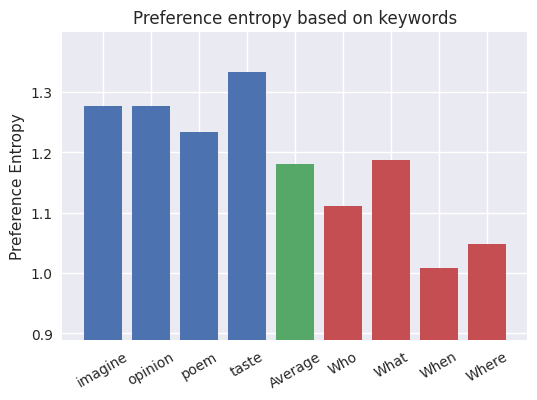

In [13]:
plt.rcParams["figure.figsize"] = (6,4)

avgs = [np.mean(d) for d in plot_data]
plt.bar(plot_labels[:4], avgs[:4])
plt.bar(plot_labels[4], avgs[4])
plt.bar(plot_labels[5:], avgs[5:])

plt.xticks(np.arange(len(avgs)), plot_labels, rotation=30)
plt.ylabel("Preference Entropy")
plt.ylim(0.89, None)
plt.title("Preference entropy based on keywords")

plt.savefig("../plots/entropy_by_keyword.png", bbox_inches="tight", dpi=300)
plt.show()

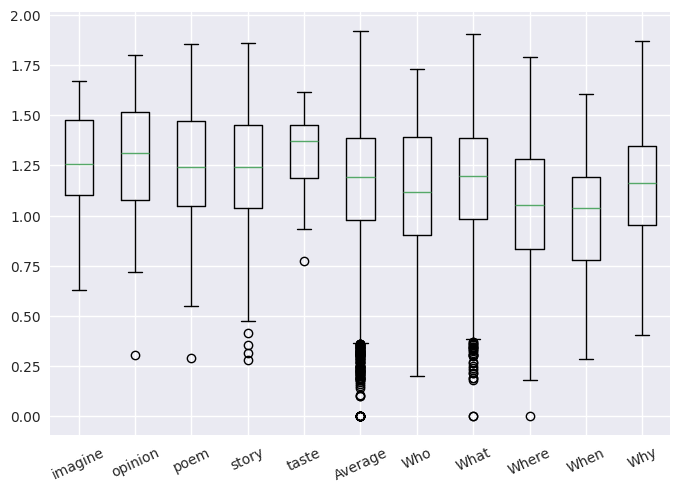

In [83]:
plt.boxplot(plot_data)
plt.xticks(np.arange(len(plot_data))+1, plot_labels, rotation=25)
plt.show()

In [71]:
for obj_word in [
    "Who", 
    "What", 
    "Where", 
    "When",
    "Why"
]:

    results = []
    sbj = []
    obj = []

    for i in range(len(data)):

        prompt = data.iloc[i]["prompt"]
        id = data.iloc[i]["id"]
        votes = list(best_choices[:,i])
        vote_dist = np.zeros(args.n_response)

        for j in range(args.n_response):
            vote_dist[j] = votes.count(j)/args.n_persons
        
        # ent = 1-np.max(vote_dist)
        ent = entropy(vote_dist)
        results.append([ent, id, prompt])

        if sbj_word in prompt:
            sbj.append(ent)
        # if obj_word in prompt:
        if obj_word.lower() == prompt.split(" ")[0].lower():
            obj.append(ent)

    sorted_results = sorted(results)

    least_ent = sorted_results[:10]
    most_ent = sorted_results[-10:]

    # print("MAX SCORE BASED")
    # print("Low Diversity")
    # for r in least_ent:
    #     print("Prompt:", r)
    # print("--------------")
    # print("High Diversity")
    # for r in most_ent:
    #     print("Prompt:", r)
        
    print()
    print(obj_word)
    print(len(sbj), len(obj))
    print(np.mean(obj), np.mean([r[0] for r in results]))


Who
127 112
1.0991660051514898 1.1644921690738248

What
127 2345
1.168877013284305 1.1644921690738248

Where
127 67
1.0327192734933752 1.1644921690738248

When
127 79
0.9954278456010791 1.1644921690738248

Why
127 224
1.144659182561106 1.1644921690738248
